# Random Forest — r/Random_Acts_Of_Pizza request fulfillment

Binary classification, AUC-optimized. Hyperparameters from `CLAUDE.md` model notes.
Goal: beat the Logistic Regression baseline of **AUC 0.6452**.

Pipeline: shared train/test split → 5-fold stratified CV → refit on full train → evaluate once on held-out test → save OOF + test probs to `predictions/`.

In [1]:
# Setup: on Colab, clone the repo so utils.py is importable and install needed packages.
# No-op when running locally with the conda env.
import os, sys, subprocess

REPO_URL = "https://github.com/JaeHub/the-free-pizza-project"
REPO_BRANCH = "random_forest"
REPO_DIR = "/content/the-free-pizza-project"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--branch", REPO_BRANCH, REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)
    os.chdir(REPO_DIR)
    subprocess.run(["pip", "install", "-q", "kagglehub"], check=True)

print("in_colab:", IN_COLAB, "| cwd:", os.getcwd())

in_colab: True | cwd: /content/the-free-pizza-project


In [2]:
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from utils import (
    TARGET_COLUMN,
    RANDOM_STATE,
    load_data,
    engineer_features,
    get_train_test_split,
    get_cv_folds,
    save_predictions,
    evaluate_cv,
    evaluate_test,
    plot_feature_importance,
    log_run,
    describe_target,
    plot_cv_fold_aucs,
    inspect_predictions,
    print_summary,
)

MODEL_NAME = "random_forest"
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


## Load & engineer features

In [3]:
df = load_data()
X = engineer_features(df)
y = df[TARGET_COLUMN].astype(int).values

print(f"Shape: {df.shape}\n")
describe_target(y, df)

text_len = (df["request_title"].fillna("") + " " + df["request_text_edit_aware"].fillna("")).str.split().str.len()
print(f"\nAvg request length : {text_len.mean():.0f} words")
print(f"Engineered features: {X.shape[1]}  →  {list(X.columns)}")
X.head()

Using Colab cache for faster access to the 'random-acts-of-pizza' dataset.
Shape: (4040, 32)

requester_received_pizza
False    3046
True      994
Name: count, dtype: int64

Class imbalance ratio: {False: 0.754, True: 0.246}

Avg request length : 89 words
Engineered features: 15  →  ['requester_account_age_in_days_at_request', 'requester_days_since_first_post_on_raop_at_request', 'requester_number_of_comments_at_request', 'requester_number_of_posts_at_request', 'requester_number_of_subreddits_at_request', 'requester_upvotes_minus_downvotes_at_request', 'request_hour', 'request_dow', 'title_word_count', 'title_char_count', 'body_word_count', 'body_char_count', 'has_url', 'has_question_mark', 'has_exclamation']


,requester_account_age_in_days_at_request,requester_days_since_first_post_on_raop_at_request,requester_number_of_comments_at_request,requester_number_of_posts_at_request,requester_number_of_subreddits_at_request,requester_upvotes_minus_downvotes_at_request,request_hour,request_dow,title_word_count,title_char_count,body_word_count,body_char_count,has_url,has_question_mark,has_exclamation
0,0.000000,0.000000,0,0,0,0,22,2,6,39,67,316,0,0,0
1,501.111100,0.000000,0,15,12,34,5,6,10,57,16,74,0,0,0
2,0.000000,0.000000,0,0,0,0,17,2,10,66,59,277,0,1,0
3,6.518438,0.000000,36,1,4,54,19,4,11,69,30,172,0,0,0
4,162.063252,101.606505,140,14,11,1121,19,4,14,81,103,490,0,0,1


## Train/test split (shared across all models)

In [4]:
train_idx, test_idx = get_train_test_split(y)
X_train, X_test = X.iloc[train_idx].reset_index(drop=True), X.iloc[test_idx].reset_index(drop=True)
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(y_train)} | Test: {len(y_test)}  (5-fold CV on train; no separate val split)")
print(f"  train pos rate: {y_train.mean():.3f}  |  test pos rate: {y_test.mean():.3f}")

Train: 3232 | Test: 808  (5-fold CV on train; no separate val split)
  train pos rate: 0.246  |  test pos rate: 0.246


## 5-fold stratified CV

Random Forest builds independent trees, so there's no early stopping or learning-curve plot. `class_weight="balanced"` handles the ~75/25 imbalance uniformly across folds — no per-fold recomputation needed.

In [5]:
BASE_PARAMS = dict(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=4,
    min_samples_split=10,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

folds = get_cv_folds(y_train)
oof_probs = np.zeros(len(y_train), dtype=float)

for fold_i, (tr_idx, val_idx) in enumerate(folds):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]

    model = RandomForestClassifier(**BASE_PARAMS)
    model.fit(X_tr, y_tr)

    oof_probs[val_idx] = model.predict_proba(X_val)[:, 1]
    fold_auc = roc_auc_score(y_val, oof_probs[val_idx])
    print(f"fold {fold_i}: val AUC={fold_auc:.4f}")

fold 0: val AUC=0.6185
fold 1: val AUC=0.6390
fold 2: val AUC=0.6540
fold 3: val AUC=0.6732
fold 4: val AUC=0.6174


In [6]:
cv_results = evaluate_cv(y_train, oof_probs, MODEL_NAME)

[random_forest] CV AUC: 0.6404 ± 0.0213  (per-fold: [np.float64(0.6185), np.float64(0.639), np.float64(0.654), np.float64(0.6732), np.float64(0.6174)], overall OOF: 0.6402)


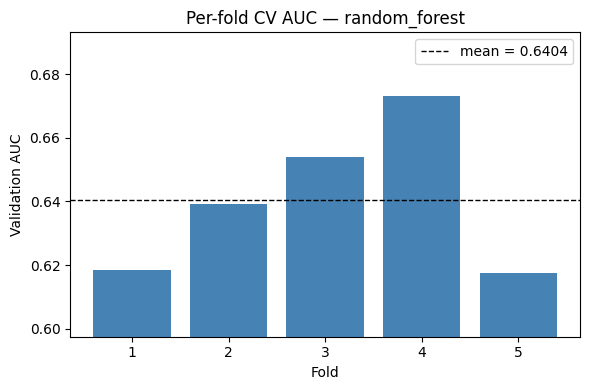

In [7]:
plot_cv_fold_aucs(cv_results["fold_aucs"], cv_results["mean"], MODEL_NAME)

## Refit on full train, evaluate once on held-out test

RF has no early stopping, so refit uses the same hyperparameters as CV — `n_estimators=300` trees on the full training set.

Refit train AUC: 0.7842
Test ROC-AUC: 0.6099

               precision    recall  f1-score   support

Not fulfilled       0.80      0.66      0.72       609
    Fulfilled       0.32      0.50      0.39       199

     accuracy                           0.62       808
    macro avg       0.56      0.58      0.56       808
 weighted avg       0.68      0.62      0.64       808



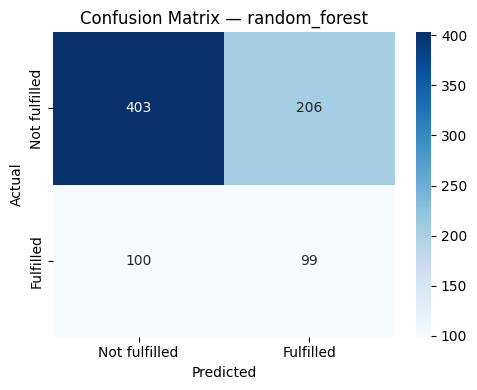

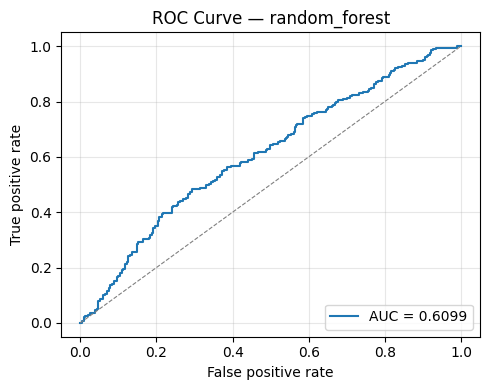

In [8]:
FINAL_PARAMS = dict(BASE_PARAMS)

final_model = RandomForestClassifier(**FINAL_PARAMS)
final_model.fit(X_train, y_train)

train_probs = final_model.predict_proba(X_train)[:, 1]
test_probs = final_model.predict_proba(X_test)[:, 1]
refit_train_auc = roc_auc_score(y_train, train_probs)
print(f"Refit train AUC: {refit_train_auc:.4f}")

test_metrics = evaluate_test(y_test, test_probs, MODEL_NAME)

## Save artifacts and inspect feature importance

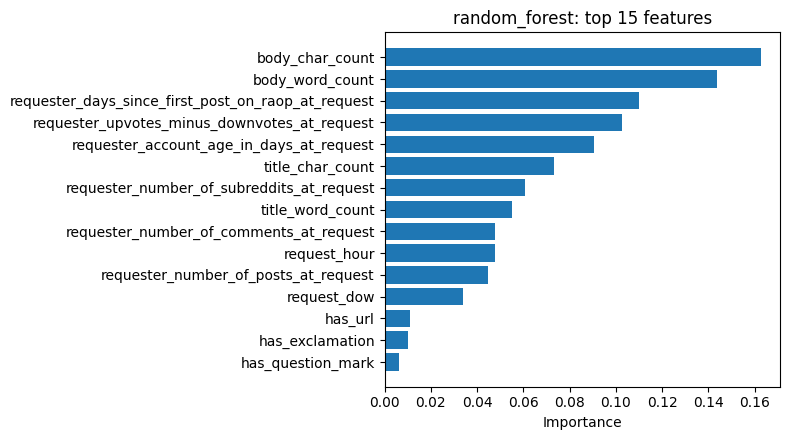

In [9]:
save_predictions(MODEL_NAME, oof_probs, test_probs)
plot_feature_importance(final_model.feature_importances_, X_train.columns, MODEL_NAME)
log_run(MODEL_NAME, FINAL_PARAMS, cv_results["mean"], cv_results["std"], test_metrics["test_auc"])

## Inspect predictions

Highest-confidence correct calls vs. confident wrong calls — same diagnostic table as `cnn_model.ipynb`.

In [10]:
y_pred = (test_probs >= 0.5).astype(int)
test_titles = df.iloc[test_idx]["request_title"].reset_index(drop=True)
inspect_predictions(test_titles, y_test, y_pred, test_probs, MODEL_NAME, n=3)

=== random_forest: Correct high-confidence predictions ===


,text,actual,confidence
690,request - i want pizza,0,0.854143
183,[Request] Craving for Pizza,0,0.845308
535,[REQUEST],0,0.843528



=== random_forest: Confident wrong predictions ===


,text,actual,predicted,confidence
720,"[request] Losing my mind, feel I fail at being...",1,0,0.823971
48,[request] Need Pizza in Boerne!,1,0,0.774600
129,[REQUEST] The 2 1/2 month old is eating but we...,0,1,0.772924


## Key Findings Summary

In [11]:
top_features = (
    pd.Series(final_model.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
    .head(3)
    .index.tolist()
)
overfit_gap = refit_train_auc - cv_results["mean"]
overfit_note = (
    "modest overfit"
    if overfit_gap < 0.05
    else "noticeable overfit (consider lowering max_depth or raising min_samples_leaf)"
)
beats_lr = test_metrics["test_auc"] > 0.6452
lr_note = (
    f"beats LR baseline (Δ = {test_metrics['test_auc']-0.6452:+.4f})"
    if beats_lr else f"below LR baseline (Δ = {test_metrics['test_auc']-0.6452:+.4f})"
)

print_summary(
    MODEL_NAME,
    dataset={
        "total_samples": len(df),
        "fulfillment_rate_pct": float(df[TARGET_COLUMN].mean() * 100),
        "n_features": X.shape[1],
    },
    model={
        "name": "Random Forest",
        "params_summary": (
            f"n_estimators={FINAL_PARAMS['n_estimators']}, max_depth={FINAL_PARAMS['max_depth']}, "
            f"min_samples_leaf={FINAL_PARAMS['min_samples_leaf']}, "
            f"min_samples_split={FINAL_PARAMS['min_samples_split']}, "
            f"max_features={FINAL_PARAMS['max_features']}"
        ),
        "class_handling": "class_weight='balanced'",
    },
    training={
        "cv_auc_mean": cv_results["mean"],
        "cv_auc_std": cv_results["std"],
        "fold_aucs": cv_results["fold_aucs"],
        "refit_train_auc": refit_train_auc,
    },
    test={
        "roc_auc": test_metrics["test_auc"],
        "f1_fulfilled": test_metrics["f1_fulfilled"],
        "accuracy_pct": test_metrics["accuracy"] * 100,
    },
    takeaways=[
        f"Test AUC {lr_note}; CNN baseline 0.5846.",
        f"Top 3 features by importance: {', '.join(top_features)}.",
        f"Refit-train vs CV AUC gap = {overfit_gap:+.4f} → {overfit_note}.",
        f"RF has no early stopping; trained {FINAL_PARAMS['n_estimators']} trees per fold and on refit.",
    ],
)

       RANDOM_FOREST — KEY FINDINGS SUMMARY

📦 Dataset
   Total samples      : 4,040
   Fulfillment rate   : 24.6%  (class imbalance 75/25)
   Features used      : 15  (leakage-safe)

🧠 Model — Random Forest
   Hyperparameters    : n_estimators=300, max_depth=6, min_samples_leaf=4, min_samples_split=10, max_features=sqrt
   Class handling     : class_weight='balanced'

📈 Cross-validation
   CV AUC             : 0.6404 ± 0.0213
   Per-fold AUCs      : [np.float64(0.6185), np.float64(0.639), np.float64(0.654), np.float64(0.6732), np.float64(0.6174)]


KeyError: 'median_best_iter'